**Этот ноутбук является упражнением из курса [Computer Vision](https://www.kaggle.com/learn/computer-vision). Вы можете обратиться к учебному пособию по [этой ссылке](https://www.kaggle.com/ryanholbrook/the-sliding-window).**

---


# Введение #

В этих упражнениях вы изучите операции, которые несколько популярных архитектур свёрточных сетей используют для извлечения признаков, узнаете, как свёрточные сети могут захватывать крупномасштабные визуальные признаки через stacking слоёв, и, наконец, увидите, как свёртка может применяться к одномерным данным, в данном случае — к временному ряду.

Запустите ячейку ниже, чтобы всё настроить.

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt

plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)
plt.rc('image', cmap='magma')

# (Необязательно) Экспериментируем с извлечением признаков #

Это упражнение предназначено для того, чтобы дать вам возможность исследовать вычисления скользящего окна и то, как их параметры влияют на извлечение признаков. Здесь нет правильных или неправильных ответов — это просто возможность поэкспериментировать!

Мы предоставили вам несколько изображений и ядер, которые вы можете использовать. Запустите эту ячейку, чтобы увидеть их.

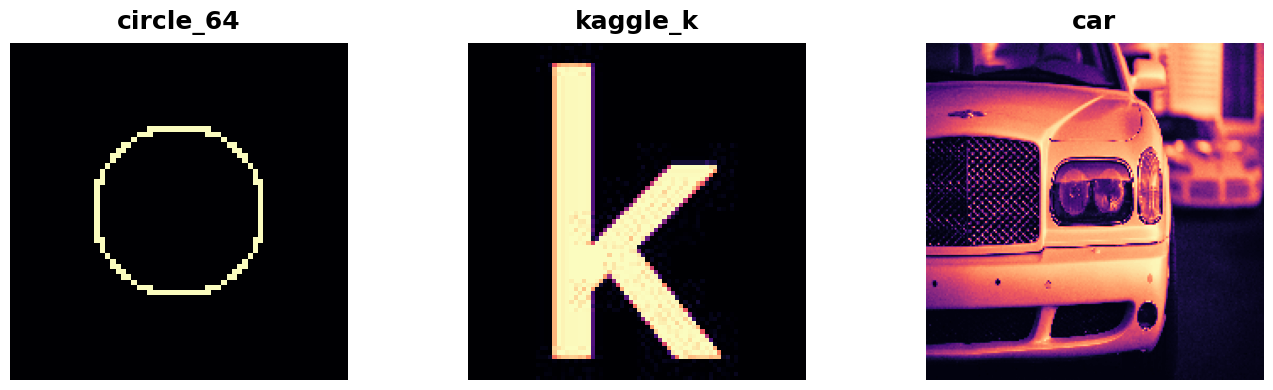

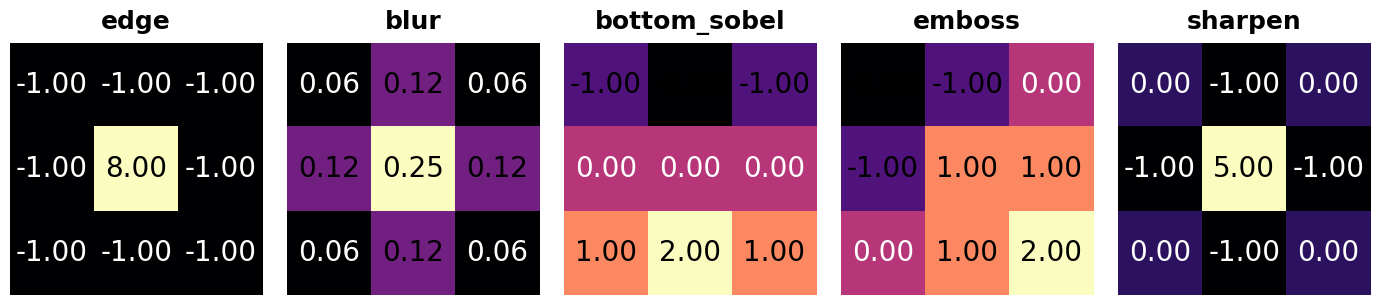

In [4]:
from src.visiontools_functions import edge, blur, bottom_sobel, emboss, sharpen, circle
import src.visiontools_functions as visiontools

image_dir = '/tf/Lessons/4._Computer_Vision/img/'
circle_64 = tf.expand_dims(circle([64, 64], val=1.0, r_shrink=4), axis=-1)
kaggle_k = visiontools.read_image(image_dir + str('k.jpg'), channels=1)
car = visiontools.read_image(image_dir + str('car_illus.jpg'), channels=1)
car = tf.image.resize(car, size=[200, 200])
images = [(circle_64, "circle_64"), (kaggle_k, "kaggle_k"), (car, "car")]

plt.figure(figsize=(14, 4))
for i, (img, title) in enumerate(images):
    plt.subplot(1, len(images), i+1)
    plt.imshow(tf.squeeze(img))
    plt.axis('off')
    plt.title(title)
plt.show();

kernels = [(edge, "edge"), (blur, "blur"), (bottom_sobel, "bottom_sobel"),
           (emboss, "emboss"), (sharpen, "sharpen")]
plt.figure(figsize=(14, 4))
for i, (krn, title) in enumerate(kernels):
    plt.subplot(1, len(kernels), i+1)
    visiontools.show_kernel(krn, digits=2, text_size=20)
    plt.title(title)
plt.show()

Чтобы выбрать изображение для экспериментов, просто введите его название в соответствующее место ниже. Затем задайте параметры для оконных вычислений. Попробуйте разные комбинации и посмотрите, что получится!

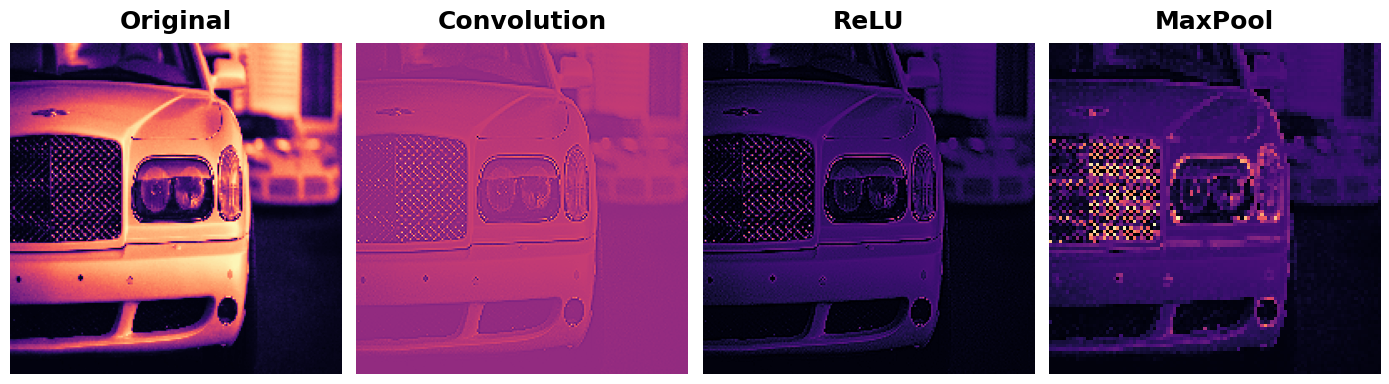

In [23]:
# YOUR CODE HERE: choose an image
image = car

# YOUR CODE HERE: choose a kernel
kernel = sharpen  # edge, blur, bottom_sobel, emboss, sharpen

visiontools.show_extraction(
    image, kernel,

    # YOUR CODE HERE: set parameters
    conv_stride=1,
    conv_padding='valid',
    pool_size=2,
    pool_stride=2,
    pool_padding='same',
    
    subplot_shape=(1, 4),
    figsize=(14, 6),
)

# Рецептивное поле #

Проследите все связи от какого-нибудь нейрона, и в конечном итоге вы достигнете входного изображения. Все пиксели входного изображения, с которыми связан нейрон, образуют его **рецептивное поле**. Рецептивное поле просто показывает, из каких частей входного изображения нейрон получает информацию.

Как мы уже видели, если ваш первый слой — это свёртка с ядрами $3 \times 3$, то каждый нейрон в этом слое получает входные данные от участка пикселей размером $3 \times 3$ (за исключением, возможно, границ).

Что произойдёт, если добавить ещё один свёрточный слой с ядрами $3 \times 3$? Рассмотрим следующую иллюстрацию:

<figure>
<img src="https://storage.googleapis.com/kaggle-media/learn/images/HmwQm2S.png" alt="Иллюстрация рецептивного поля двух stacked свёрток." width=250>
</figure>

Теперь проследите связи от нейрона наверху, и вы увидите, что он связан с участком пикселей $5 \times 5$ на входе (нижний слой): каждый нейрон в участке $3 \times 3$ среднего слоя связан с участком входа $3 \times 3$, но они перекрываются, образуя участок $5 \times 5$. Таким образом, этот нейрон наверху имеет рецептивное поле $5 \times 5$.

# 1) Увеличение рецептивного поля #

Теперь, если вы добавите *третий* свёрточный слой с ядром `(3, 3)`, какое рецептивное поле будут иметь его нейроны? Запустите ячейку ниже, чтобы узнать ответ. (Или сначала посмотрите подсказку!)

In [ ]:
Правильно:

 У третьего слоя будет 7 x 7 рецептивное поле.

In [ ]:
Подсказка: при добавлении второго слоя рецептивное поле расширяется на один нейрон с каждой стороны, что дает 
 для каждого измерения 3+1+1=5. Что получится, если снова расширить поле на один нейрон?

Так зачем же stacking слоёв таким образом? Три ядра `(3, 3)` имеют 27 параметров, в то время как одно ядро `(7, 7)` — 49, хотя оба создают одинаковое рецептивное поле. Этот трюк со stacking слоёв — один из способов, с помощью которого свёрточные сети могут создавать большие рецептивные поля без значительного увеличения количества параметров. Вы увидите, как сделать это самостоятельно, на следующем уроке!

# (Необязательно) Одномерная свёртка #

Свёрточные сети оказываются полезными не только для (двумерных) изображений, но и для таких вещей, как временные ряды (одномерные) и видео (трёхмерные).

Мы видели, как свёрточные сети могут научиться извлекать признаки из (двумерных) изображений. Оказывается, свёрточные сети также могут научиться извлекать признаки из временных рядов (одномерных) и видео (трёхмерных).

В этом (необязательном) упражнении мы посмотрим, как выглядит свёртка на временном ряде.

Временной ряд, который мы будем использовать, взят из [Google Trends](https://trends.google.com/trends/). Он измеряет популярность поискового запроса "machine learning" по неделям с 25 января 2015 года по 15 января 2020 года.

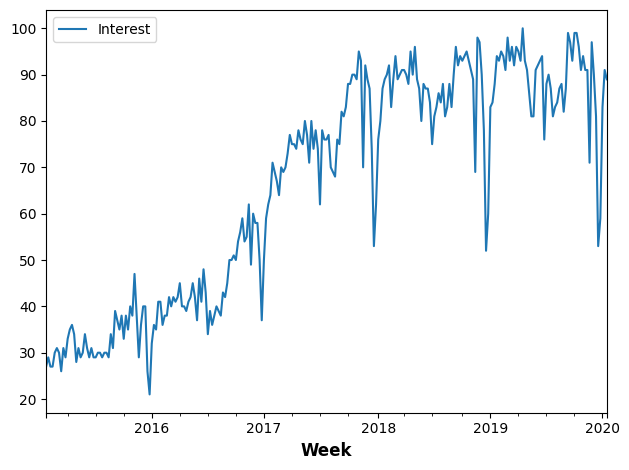

In [8]:
import pandas as pd

# Load the time series as a Pandas dataframe
machinelearning = pd.read_csv(
    '/tf/Lessons/4._Computer_Vision/data/machinelearning.csv',
    parse_dates=['Week'],
    index_col='Week',
)

machinelearning.plot();

А как насчёт ядер? Изображения двумерны, поэтому наши ядра были двумерными массивами. Временной ряд одномерен, так каким же должно быть ядро? Одномерным массивом! Вот некоторые ядра, иногда используемые для данных временных рядов:

In [9]:
detrend = tf.constant([-1, 1], dtype=tf.float32)

average = tf.constant([0.2, 0.2, 0.2, 0.2, 0.2], dtype=tf.float32)

spencer = tf.constant([-3, -6, -5, 3, 21, 46, 67, 74, 67, 46, 32, 3, -5, -6, -3], dtype=tf.float32) / 320

Свёртка последовательности работает так же, как свёртка изображения. Разница лишь в том, что скользящее окно в последовательности движется только в одном направлении — слева направо — вместо двух направлений на изображении. И, как и прежде, извлекаемые признаки зависят от числового паттерна в ядре.

Можете ли вы угадать, какие именно признаки извлекают эти ядра? Раскомментируйте одно из ядер ниже и запустите ячейку, чтобы увидеть!

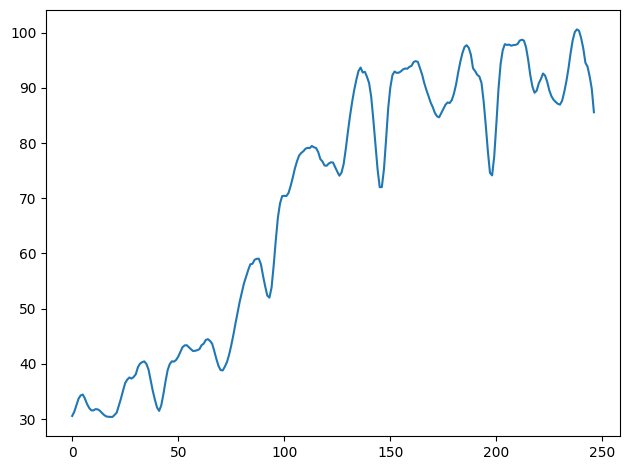

In [12]:
# UNCOMMENT ONE
# kernel = detrend
# kernel = average
kernel = spencer

# Reformat for TensorFlow
ts_data = machinelearning.to_numpy()
ts_data = tf.expand_dims(ts_data, axis=0)
ts_data = tf.cast(ts_data, dtype=tf.float32)
kern = tf.reshape(kernel, shape=(*kernel.shape, 1, 1))

ts_filter = tf.nn.conv1d(
    input=ts_data,
    filters=kern,
    stride=1,
    padding='VALID',
)

# Format as Pandas Series
machinelearning_filtered = pd.Series(tf.squeeze(ts_filter).numpy())

machinelearning_filtered.plot();

На самом деле, ядро `detrend` фильтрует *изменения* в ряде, в то время как `average` и `spencer` являются "сглаживателями", которые фильтруют низкочастотные компоненты ряда.

Если бы вы были заинтересованы в прогнозировании будущей популярности поисковых запросов, вы могли бы обучить свёрточную сеть на таком временном ряде. Она пыталась бы изучить, какие признаки в этих рядах наиболее информативны для прогноза.

Хотя свёрточные сети сами по себе часто не являются наилучшим выбором для таких задач, они часто включаются в другие модели благодаря своим способностям к извлечению признаков.

# Заключение #

Этот урок завершает наше обсуждение извлечения признаков. Надеюсь, после прохождения этих уроков вы получили некоторое представление о том, как работает этот процесс и почему обычные варианты его реализации часто являются наилучшими.

# Продолжаем обучение #

На следующем уроке, [**Урок 5**](https://www.kaggle.com/ryanholbrook/custom-convnets), вы узнаете, как компоновать слои `Conv2D` и `MaxPool2D` для создания собственных свёрточных сетей с нуля.

---




*Есть вопросы или комментарии? Посетите [форум обсуждения курса](https://www.kaggle.com/learn/computer-vision/discussion), чтобы пообщаться с другими учащимися.*